<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/tensorflow/lenet5_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.7 MB/s eta 0:00:00


In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



In [31]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import cifar10
from keras.layers import Input, Conv2D, AveragePooling2D, MaxPooling2D, Dense, Flatten, Dropout, Activation, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.utils import to_categorical
# from keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2
from keras.callbacks import Callback, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time

In [4]:
print(tf.__version__)

2.19.0


In [5]:
# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("Num GPUs Available: ", len(gpus))
    for gpu in gpus:
        print(f"GPU: {gpu}")
else:
    print("No GPU available.")


#------------------------------------------------------------------------------------------------------------------------
# Verify TensorFlow is using GPU
if tf.test.gpu_device_name():
    print('GPU found: {}'.format(tf.test.gpu_device_name()))
else:
    print("GPU not found.")

Num GPUs Available:  1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU found: /device:GPU:0


---
# 0. Model Settings

---

In [32]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 42
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 30

# Architecture
INPUT_SHAPE = (32, 32, 3) # CIFAR-10 is 32x32 pixels, 3 color channels
NUM_CLASSES = 10

# Other
GRAYSCALE = False

---
# 1. Data Preparation & Loading

---

In [9]:
# 1. Load the CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train.shape, type(x_train)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


((50000, 32, 32, 3), numpy.ndarray)

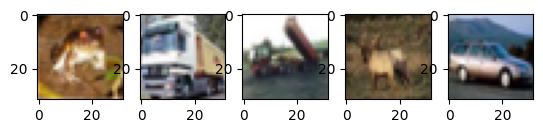

In [10]:
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(x_train[i, :, :])

In [12]:
def preprocess_data(cifar_data, split_ratio=0.08, batch_size=32, num_classes=10, preprocess_type='normalize', random_seed=42):
    """
    Preprocess CIFAR-10 data with specified method and return TensorFlow datasets.

    Args:
        cifar_data: Tuple containing the CIFAR-10 data.
        # ... (rest of args remain the same)
    """
    (train_images, train_labels), (test_images, test_labels) = cifar_data

    # Convert to float32 (important for normalization)
    train_images = train_images.astype('float32')
    test_images = test_images.astype('float32')

    # Note: No need to reshape/resize as CIFAR-10 is already (32, 32, 3)

    if preprocess_type == 'normalize':
        # Normalize pixel values to [0, 1]
        train_images = train_images / 255.0
        test_images = test_images / 255.0

    elif preprocess_type == 'standardize':
        # Standardize pixel values (mean 0, std 1)
        mean_px = tf.reduce_mean(train_images).numpy().astype(float)
        std_px = tf.math.reduce_std(train_images).numpy().astype(float)

        train_images = (train_images - mean_px) / std_px
        test_images = (test_images - mean_px) / std_px

    else:
        raise ValueError("Invalid preprocess_type. Choose 'normalize' or 'standardize'.")

    # Convert labels to one-hot encoding (10 classes for CIFAR-10)
    train_labels = to_categorical(train_labels, num_classes=num_classes)
    test_labels = to_categorical(test_labels, num_classes=num_classes)

    # Split the training data into training and validation sets
    num_val_samples = int(split_ratio * len(train_images))
    val_images = train_images[-num_val_samples:]
    val_labels = train_labels[-num_val_samples:]
    train_images = train_images[:-num_val_samples]
    train_labels = train_labels[:-num_val_samples]

    # Create TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

    # Shuffle and batch datasets
    train_dataset = train_dataset.shuffle(buffer_size=len(train_images), seed=random_seed).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_dataset, val_dataset, test_dataset

In [33]:
# Load CIFAR data
mnist_data = cifar10.load_data()

# Preprocess data with normalization and a fixed random seed
train_dataset, val_dataset, test_dataset = preprocess_data(
    mnist_data, split_ratio=0.08, batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,preprocess_type='normalize',
    random_seed=RANDOM_SEED)


In [34]:
# Assuming train_dataset is your tf.data.Dataset
for images, labels in train_dataset.take(1):  # Take one batch
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (128, 32, 32, 3)
Label shape: (128, 10)


---
# 2. Model Creation

---

In [35]:
def LeNet5(input_shape, num_classes):
    model = Sequential([
        # C1: Convolutional Layer (6 filters)
        Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
               input_shape=input_shape, padding='same'), # Input shape is (32, 32, 3)

        # S2: Pooling Layer (2x2 average pooling)
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C3: Convolutional Layer (16 filters)
        Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # S4: Pooling Layer (2x2 average pooling)
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C5: Fully Connected Convolutional Layer (120 units)
        Flatten(),
        Dense(120, activation='tanh'),

        # F6: Fully Connected Layer (84 units)
        Dense(84, activation='tanh'),

        # Output Layer (10 units for CIFAR-10)
        Dense(num_classes, activation='softmax')
    ])
    return model

---
# 3. Model Compiling, Training, Testing & Evaluation

---

In [36]:
def train_model(model, train_dataset, val_dataset, NUM_EPOCHS=20, lr_factor=0.2, lr_patience=2):
    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    class LogMetrics(Callback):
        def __init__(self, num_epochs):
            super(LogMetrics, self).__init__()
            self.num_epochs = num_epochs
            self.lrs = []

        def on_train_begin(self, logs=None):
            self.lrs = []

        def on_epoch_end(self, epoch, logs=None):
            # Val metrics are available in logs thanks to validation_data=val_dataset
            val_loss = logs.get('val_loss')
            val_accuracy = logs.get('val_accuracy')
            lr = self.model.optimizer.learning_rate.numpy()
            self.lrs.append(lr)

            print(f'Epoch {epoch + 1}/{self.num_epochs} | '
                  f'Train Loss: {logs["loss"]:.5f}, '
                  f'Train Accuracy: {logs["accuracy"]:.5f} | '
                  f'Val Loss: {val_loss:.5f}, '
                  f'Val Accuracy: {val_accuracy:.5f} | '
                  f'Learning Rate: {lr:.8f}')

    # Define the ReduceLROnPlateau callback
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=lr_factor,
        patience=lr_patience,
        verbose=1
    )

    # Create an instance of the LogMetrics callback
    log_metrics = LogMetrics(NUM_EPOCHS)

    # Train the model
    start_time = time.time()
    history = model.fit(train_dataset,
                        epochs=NUM_EPOCHS,
                        validation_data=val_dataset,
                        callbacks=[log_metrics, reduce_lr],
                        verbose=0) # verbosity is 0 since logging is handled by LogMetrics

    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))
    return model, history, log_metrics, reduce_lr

In [37]:
# Plot the training history
def plot_history(history, lrs):
    epochs = range(len(history.history['loss']))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, lrs, label='Learning Rate')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [38]:
# Instantiate the model with CIFAR-10 parameters
model = LeNet5(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30 | Train Loss: 1.81991, Train Accuracy: 0.35693 | Val Loss: 1.73176, Val Accuracy: 0.40200 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.64976, Train Accuracy: 0.41954 | Val Loss: 1.60908, Val Accuracy: 0.44250 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.52808, Train Accuracy: 0.46183 | Val Loss: 1.51658, Val Accuracy: 0.46375 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 1.43428, Train Accuracy: 0.49296 | Val Loss: 1.43028, Val Accuracy: 0.49500 | Learning Rate: 0.00100000
Epoch 5/30 | Train Loss: 1.36329, Train Accuracy: 0.51724 | Val Loss: 1.39136, Val Accuracy: 0.50600 | Learning Rate: 0.00100000
Epoch 6/30 | Train Loss: 1.30627, Train Accuracy: 0.53876 | Val Loss: 1.35290, Val Accuracy: 0.52350 | Learning Rate: 0.00100000
Epoch 7/30 | Train Loss: 1.26074, Train Accuracy: 0.55267 | Val Loss: 1.33696, Val Accuracy: 0.53425 | Learning Rate: 0.00100000
Epoch 8/30 | Train Loss: 1.21610, Train Accuracy: 0.56920 | Val Loss: 1.31780, Val Accuracy: 0.54

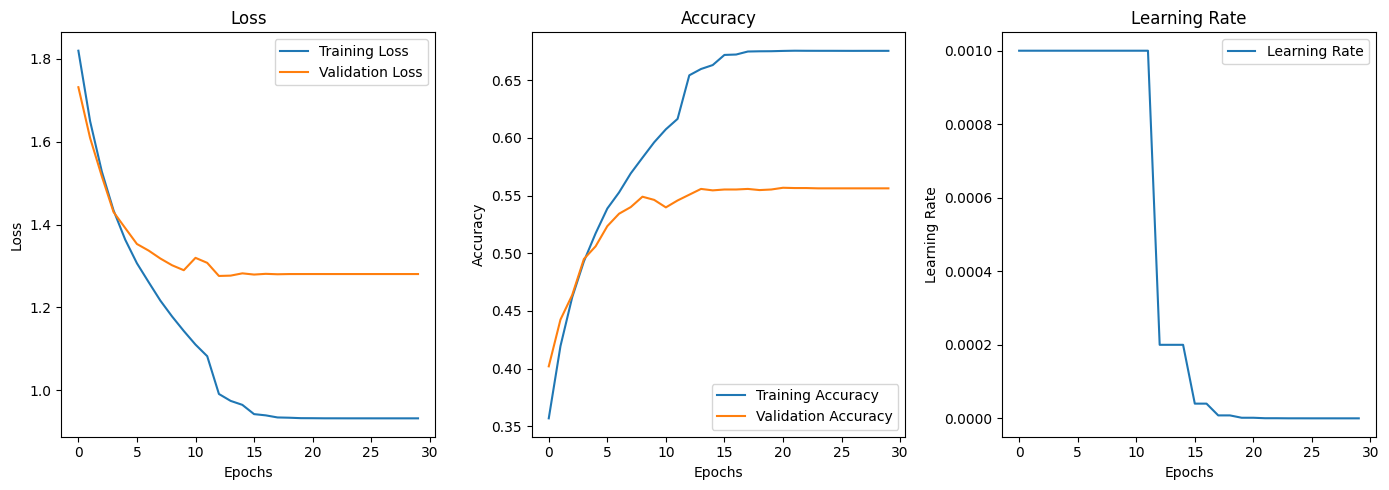

In [39]:
NUM_EPOCHS = 30 # A higher number is often needed for CIFAR-10

model, history, log_metrics, reduce_lr = train_model(model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history, log_metrics.lrs)

---
# 4. Model Improvement: Scaling Factor Via Kernels

---

In [40]:
def scaled_LeNet5(input_shape, num_classes):

    # 1. Determine the channel factor (3 for CIFAR-10)
    channel_factor = input_shape[-1]

    # 2. Define the scaled kernel counts based on the channel factor
    C1_KERNELS = 6 * channel_factor      # 6 * 3 = 18 kernels
    C3_KERNELS = 16 * channel_factor     # 16 * 3 = 48 kernels
    FC5_UNITS = 120 * channel_factor     # 120 * 3 = 360 units
    F6_UNITS = 84 * channel_factor       # 84 * 3 = 252 units

    model = Sequential([
        # C1: Convolutional Layer
        Conv2D(C1_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
               input_shape=input_shape, padding='same'),

        # S2: Pooling Layer
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C3: Convolutional Layer
        Conv2D(C3_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # S4: Pooling Layer
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # --- Classifier Block ---

        # Flatten before Dense layers
        Flatten(),

        # C5 / FC5: Fully Connected Layer
        Dense(FC5_UNITS, activation='tanh'),

        # F6: Fully Connected Layer
        Dense(F6_UNITS, activation='tanh'),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model


In [41]:

# Make model and print model summary
scaled_model = scaled_LeNet5(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
scaled_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 18)     │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 16, 16, 18)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 48)     │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 6, 6, 48)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 360)            │       622,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 252)            │        90,972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,958 (2.82 MB)

 Trainable params: 738,958 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30 | Train Loss: 1.80595, Train Accuracy: 0.36430 | Val Loss: 1.70466, Val Accuracy: 0.39775 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.60661, Train Accuracy: 0.43593 | Val Loss: 1.53986, Val Accuracy: 0.45575 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.43616, Train Accuracy: 0.48950 | Val Loss: 1.42099, Val Accuracy: 0.50300 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 1.32176, Train Accuracy: 0.53104 | Val Loss: 1.34397, Val Accuracy: 0.52700 | Learning Rate: 0.00100000
Epoch 5/30 | Train Loss: 1.23020, Train Accuracy: 0.56435 | Val Loss: 1.33143, Val Accuracy: 0.53225 | Learning Rate: 0.00100000
Epoch 6/30 | Train Loss: 1.13198, Train Accuracy: 0.60172 | Val Loss: 1.29029, Val Accuracy: 0.54900 | Learning Rate: 0.00100000
Epoch 7/30 | Train Loss: 1.03768, Train Accuracy: 0.63533 | Val Loss: 1.30155, Val Accuracy: 0.55675 | Learning Rate: 0.00100000
Epoch 8/30 | Train Loss: 0.95006, Train Accuracy: 0.66883 | Val Loss: 1.30514, Val Accuracy: 0.55

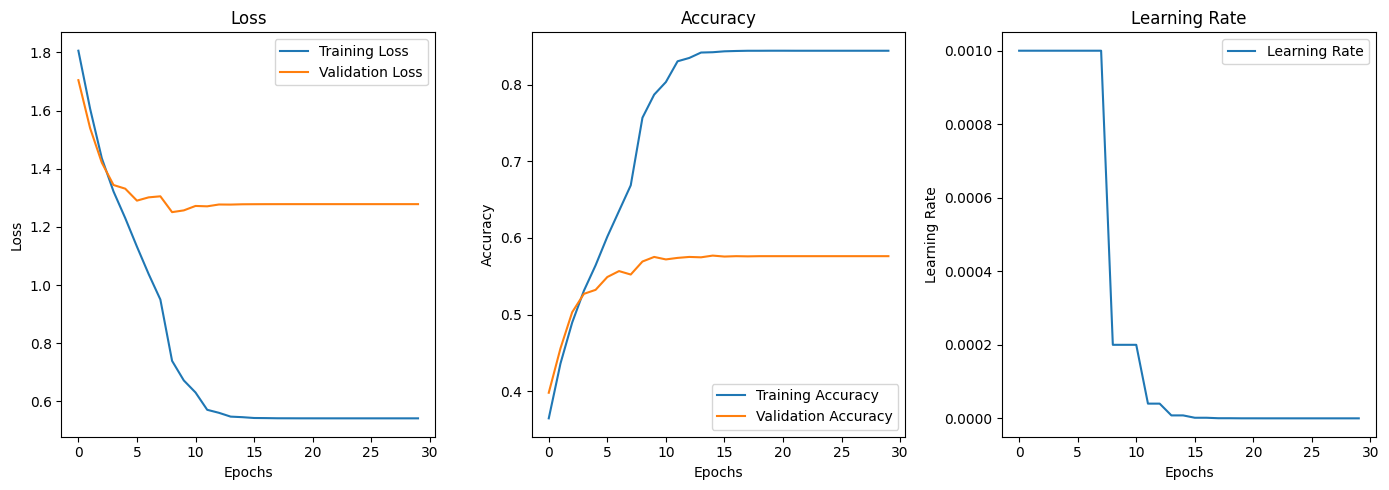

In [42]:
scaled_model, history_scaled, log_metrics_scaled, reduce_lr_scaled = train_model(scaled_model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data
test_loss_scaled, test_acc_scaled = scaled_model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss_scaled:.4f}, Test Accuracy: {test_acc_scaled:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history_scaled, log_metrics_scaled.lrs)

---
# 5. Model Improvements 2

---
The changes made are listed below:

1.   Replace all instances of `tanh` activation function with `ReLU` except the final output layer.
2.   Replace all instances of `AveragePooling2D` to `MaxPooling2D`
3.   Add `Dropout()` after 2nd pooling layer and the fully connected (FC) layer.
4.  Add `BatchNormalization()` after every `Conv2D` layer and potentially the fully connected layer.



In [44]:
def LeNet5v1(input_shape, num_classes):

    # Use 3 channels for CIFAR-10
    channel_factor = input_shape[-1]

    # Scaled kernel/unit counts
    C1_KERNELS = 6 * channel_factor     # 18
    C3_KERNELS = 16 * channel_factor    # 48
    FC5_UNITS = 120 * channel_factor    # 360
    F6_UNITS = 84 * channel_factor      # 252

    model = Sequential([
        # C1: Convolutional Layer
        Conv2D(C1_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='relu', # <--- RELU
               input_shape=input_shape, padding='same'),
        BatchNormalization(), # <--- BATCH NORM

        # S2: Pooling Layer
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)), # <--- MAX POOL

        # C3: Convolutional Layer
        Conv2D(C3_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid'), # <--- RELU
        BatchNormalization(), # <--- BATCH NORM

        # S4: Pooling Layer
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)), # <--- MAX POOL
        Dropout(0.25), # <--- DROPOUT

        # --- Classifier Block ---

        Flatten(),

        # C5 / FC5: Fully Connected Layer
        Dense(FC5_UNITS, activation='relu'), # <--- RELU
        BatchNormalization(), # <--- BATCH NORM
        Dropout(0.5), # <--- DROPOUT (higher rate for dense layers)

        # F6: Fully Connected Layer
        Dense(F6_UNITS, activation='relu'), # <--- RELU

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model


In [45]:
# Create the model & Print out model summary
LeNet5v1_model = LeNet5v1(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
LeNet5v1_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 18)     │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 18)     │            72 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 18)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 48)     │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 360)            │       622,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 360)            │         1,440 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 252)            │        90,972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,662 (2.83 MB)

 Trainable params: 739,810 (2.82 MB)

 Non-trainable params: 852 (3.33 KB)

Epoch 1/30 | Train Loss: 1.59356, Train Accuracy: 0.43959 | Val Loss: 2.24969, Val Accuracy: 0.28725 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.23219, Train Accuracy: 0.55989 | Val Loss: 1.21133, Val Accuracy: 0.56325 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.06751, Train Accuracy: 0.62296 | Val Loss: 1.12657, Val Accuracy: 0.59900 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 0.96499, Train Accuracy: 0.65883 | Val Loss: 0.92087, Val Accuracy: 0.68050 | Learning Rate: 0.00100000
Epoch 5/30 | Train Loss: 0.89408, Train Accuracy: 0.68376 | Val Loss: 0.94579, Val Accuracy: 0.66850 | Learning Rate: 0.00100000
Epoch 6/30 | Train Loss: 0.82878, Train Accuracy: 0.70461 | Val Loss: 0.98221, Val Accuracy: 0.65725 | Learning Rate: 0.00100000

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
Epoch 7/30 | Train Loss: 0.70562, Train Accuracy: 0.75143 | Val Loss: 0.74983, Val Accuracy: 0.74600 | Learning Rate: 0.00020000
Epoch 8/30 | Train 

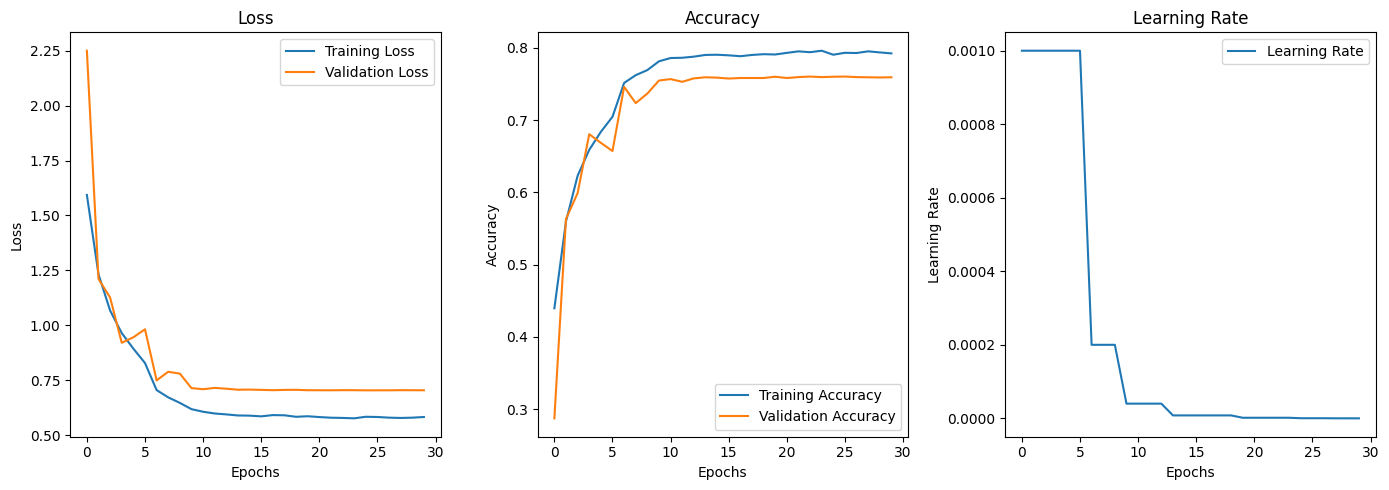

In [47]:
LeNet5v1_model, history_v1, log_metrics_v1, reduce_lr_v1 = train_model(LeNet5v1_model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data using model
test_loss_v1, test_accuracy_v1 = LeNet5v1_model.evaluate(test_dataset)
print(f'Test Loss: {test_loss_v1:.4f}, Test Accuracy: {test_accuracy_v1:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history_v1, log_metrics_v1.lrs)